# Altum and REMX (UAV multispectral cameras): uncertainty budget and vegetation indices, Plot 103

**Reference:** Werfeli, M., Antala, M., Abdelmajeed, A.Y.A., Sánchez-Virosta, Á., Halem, Z., Merrington, A., El-Mejjaouy, Y., Petrovic, B., Hueni, A., Bouras, E.H., Kefauver, S.C., Shafiee, S., Rastogi, A., Mihai, L. (2026). *Uncertainty propagation and intercomparison of multi-sensor measurements of vegetation stress in sub-optimal conditions.* Precision Agric 27, 153. https://doi.org/10.1007/s11119-026-10455-1

In [1]:
# =====================================================================================
# OVERVIEW
# INPUT DATA        : plot-level reflectance of Plot 103 (Norway campaign, 2025) for two UAV cameras,
#                     Altum (5 bands) and REMX (10 bands), each calibrated in two ways:
#                       GP = manufacturer grey-panel workflow, WP = manual white-panel correction.
#                     Source: the campaign workbook Indexes-7_cos_16062026.xlsx, sheet Reflectance_103_all (one block of
#                     columns per camera and method, one row per band: wavelength, R, u_panel, u_plot, u_ROI, u_total)
#                     and sheet Indexes103 (vegetation indices of each camera and method with their uncertainty).
#                     (orthomosaic generation and ROI extraction are done before this notebook)
# ASSUMPTIONS       : the three uncertainty components are independent;
#                     u_panel = 0 for the grey-panel workflow (no white reference correction applied).
# UNCERTAINTY MODEL : u_total = sqrt(u_panel^2 + u_plot^2 + u_roi^2)
# STEPS             : 1 load the data
#                     2 compare the two calibration methods (GP vs WP)
#                     3 combine the three uncertainty components
#                     4 relative uncertainty and dominant component
#                     5 vegetation indices from the reflectance
#                     6 vegetation indices and their uncertainty (workbook)
# OUTPUT            : plots and tables below; vegetation indices per camera and calibration method
# =====================================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openpyxl

plt.rcParams.update({'font.size': 14})

## Step 1 - Load the data

In [2]:
# Step 1: read the reflectance and its uncertainty components from the campaign workbook, sheet Reflectance_103_all.
# One block of 6 columns per camera and calibration method, data from row 3:
#   Altum GP: columns AK-AP (37-42), Altum WP: AQ-AV (43-48), REMX GP: AW-BB (49-54), REMX WP: BC-BH (55-60)
#   columns of a block: wavelength, R, u_panel, u_plot, u_ROI, u_total
FILE = "../data/case-intercomparison-plot103-full/Indexes-7_cos_16062026.xlsx"
wb = openpyxl.load_workbook(FILE, data_only=True, read_only=True)
ws = wb["Reflectance_103_all"]
rows = list(ws.iter_rows(min_row=3, max_row=40, min_col=37, max_col=60, values_only=True))

def read_block(first_col):
    k = first_col - 37
    data = [r[k:k + 6] for r in rows if r[k] is not None]
    return pd.DataFrame(data, columns=['wvl', 'R', 'u_panel', 'u_plot', 'u_roi', 'u_total'], dtype=float)

altum_gp = read_block(37)
altum_wp = read_block(43)
remx_gp  = read_block(49)
remx_wp  = read_block(55)

# the cameras are multispectral: a handful of fixed band centres instead of a continuous spectrum
print("Altum bands:", altum_gp['wvl'].tolist())
print("REMX bands:", remx_gp['wvl'].tolist())

Altum bands: [475.0, 560.0, 842.0, 668.0, 717.0]
REMX bands: [444.0, 475.0, 531.0, 560.0, 842.0, 650.0, 668.0, 705.0, 717.0, 740.0]


## Step 2 - Grey panel (GP) versus white panel (WP)

Text(0.5, 0.98, 'Plot 103 - same imagery, two calibration methods')

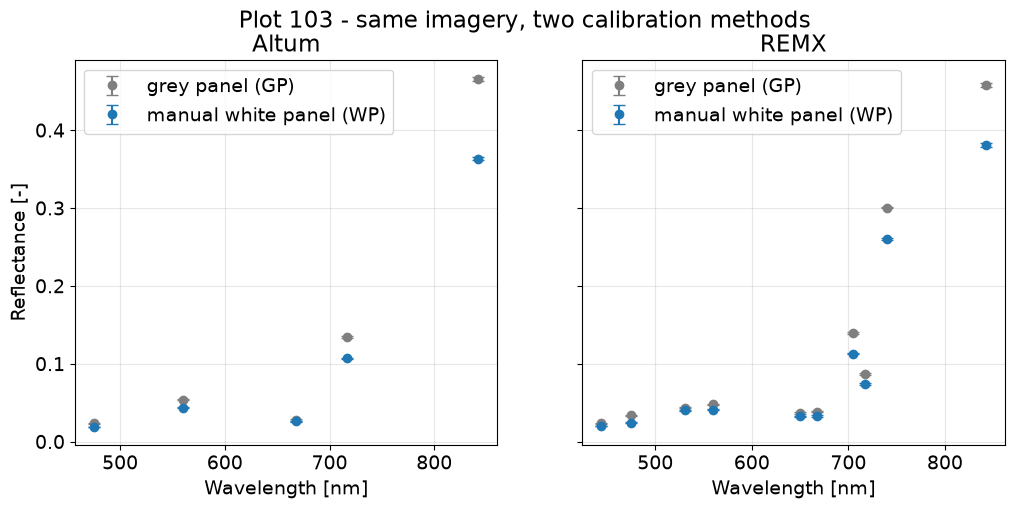

In [3]:
# Step 2a: plot reflectance with its combined uncertainty (u_total) for both calibration methods.
# Points with error bars are used because the data are sparse (one value per band).
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, gp, wp, name in zip(axs, [altum_gp, remx_gp], [altum_wp, remx_wp], ['Altum', 'REMX']):
    gp_sorted, wp_sorted = gp.sort_values('wvl'), wp.sort_values('wvl')
    ax.errorbar(gp_sorted['wvl'], gp_sorted['R'], yerr=gp_sorted['u_total'], fmt='o', capsize=4,
                label='grey panel (GP)', color='tab:gray')
    ax.errorbar(wp_sorted['wvl'], wp_sorted['R'], yerr=wp_sorted['u_total'], fmt='o', capsize=4,
                label='manual white panel (WP)', color='tab:blue')
    ax.set_xlabel('Wavelength [nm]')
    ax.set_title(name)
    ax.legend()
    ax.grid(alpha=0.3)
axs[0].set_ylabel('Reflectance [-]')
fig.suptitle('Plot 103 - same imagery, two calibration methods')

In [4]:
# Step 2b: relative difference between the two methods, band by band:
# |R_GP - R_WP| / R_GP  (in %). The difference between two independent calibration methods
# is a measure of the method-dependent part of the uncertainty.
for gp, wp, name in [(altum_gp, altum_wp, 'Altum'), (remx_gp, remx_wp, 'REMX')]:
    merged = gp.merge(wp, on='wvl', suffixes=('_gp', '_wp'))
    merged['rel_diff_pct'] = (merged['R_gp'] - merged['R_wp']).abs() / merged['R_gp'] * 100
    print(f"--- {name}: GP vs WP relative difference by band ---")
    print(merged[['wvl', 'R_gp', 'R_wp', 'rel_diff_pct']].round(4).to_string(index=False))
    print()

--- Altum: GP vs WP relative difference by band ---
  wvl   R_gp   R_wp  rel_diff_pct
475.0 0.0237 0.0187       20.9807
560.0 0.0539 0.0433       19.7366
842.0 0.4652 0.3635       21.8668
668.0 0.0280 0.0258        7.6450
717.0 0.1342 0.1068       20.4532

--- REMX: GP vs WP relative difference by band ---
  wvl   R_gp   R_wp  rel_diff_pct
444.0 0.0233 0.0199       14.3680
475.0 0.0337 0.0242       28.1352
531.0 0.0432 0.0403        6.5696
560.0 0.0481 0.0408       15.1117
842.0 0.4582 0.3813       16.7930
650.0 0.0368 0.0323       12.3605
668.0 0.0385 0.0332       13.8550
705.0 0.1394 0.1128       19.0434
717.0 0.0863 0.0741       14.1672
740.0 0.3004 0.2606       13.2612



## Step 3 - Combined uncertainty from its components

In [5]:
# Step 3: combine the three independent components in quadrature,
#   u_combined = sqrt(u_panel^2 + u_plot^2 + u_roi^2)
#   u_panel : calibration uncertainty of the panel (zero for the grey-panel workflow)
#   u_plot  : spread of the reflectance within the plot ROI
#   u_roi   : sensitivity to the ROI placement (original ROI versus shifted / buffered ROIs)
# The u_total column of the data files is this combination.
for df, name in [(altum_gp, 'Altum GP'), (altum_wp, 'Altum WP'), (remx_gp, 'REMX GP'), (remx_wp, 'REMX WP')]:
    df['u_combined'] = np.sqrt(df['u_panel']**2 + df['u_plot']**2 + df['u_roi']**2)
    print(f"--- {name} ---")
    print(df[['wvl', 'u_panel', 'u_plot', 'u_roi', 'u_combined']].round(6).to_string(index=False))
    print()

--- Altum GP ---
  wvl  u_panel   u_plot    u_roi  u_combined
475.0      0.0 0.000080 0.000643    0.000648
560.0      0.0 0.000116 0.000749    0.000758
842.0      0.0 0.000705 0.002416    0.002517
668.0      0.0 0.000140 0.001206    0.001214
717.0      0.0 0.000200 0.000747    0.000773

--- Altum WP ---
  wvl  u_panel   u_plot    u_roi  u_combined
475.0 0.000079 0.000063 0.000508    0.000518
560.0 0.000182 0.000093 0.000601    0.000635
842.0 0.001527 0.000551 0.001888    0.002490
668.0 0.000109 0.000129 0.001113    0.001125
717.0 0.000448 0.000159 0.000593    0.000760

--- REMX GP ---
  wvl  u_panel   u_plot    u_roi  u_combined
444.0      0.0 0.000095 0.000535    0.000543
475.0      0.0 0.000080 0.000465    0.000472
531.0      0.0 0.000114 0.000554    0.000565
560.0      0.0 0.000138 0.000600    0.000616
842.0      0.0 0.000914 0.002089    0.002280
650.0      0.0 0.000210 0.001208    0.001226
668.0      0.0 0.000212 0.001191    0.001210
705.0      0.0 0.000272 0.000793    0.000838
717

## Step 4 - Relative uncertainty and dominant component

In [6]:
# Step 4a: combined uncertainty relative to the reflectance (in %), and the component that
# is largest on average over the bands (white-panel method).
for df, name in [(altum_wp, 'Altum (WP)'), (remx_wp, 'REMX (WP)')]:
    df['u_total_pct'] = df['u_total'] / df['R'] * 100
    dominant = df[['u_panel', 'u_plot', 'u_roi']].mean().idxmax()
    print(f"{name}: relative combined uncertainty {df['u_total_pct'].min():.2f}%-{df['u_total_pct'].max():.2f}%  "
          f"(dominant component on average: {dominant})")

Altum (WP): relative combined uncertainty 0.68%-4.36%  (dominant component on average: u_roi)
REMX (WP): relative combined uncertainty 0.55%-3.36%  (dominant component on average: u_roi)


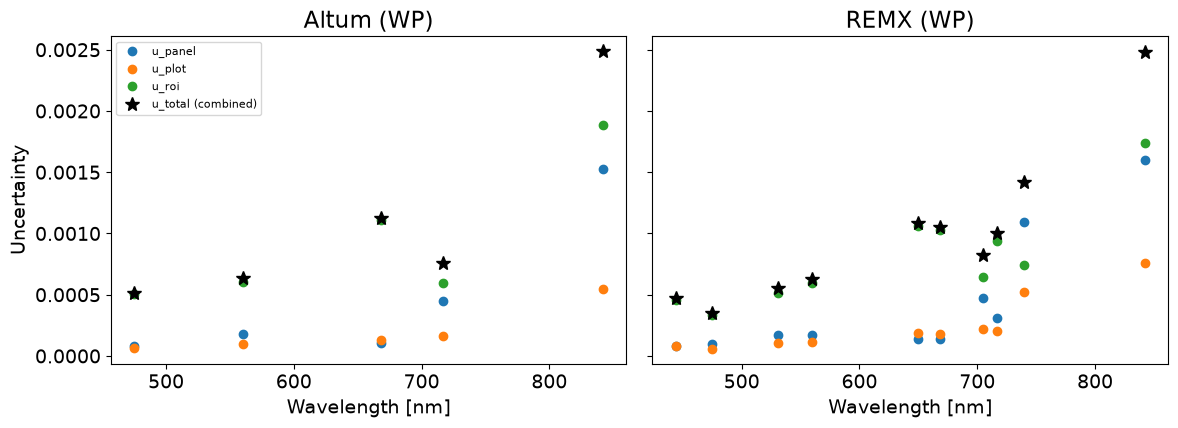

In [7]:
# Step 4b: uncertainty components per band (points, because the bands are discrete);
# the black star is the combined uncertainty.
fig, axs = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, df, name in zip(axs, [altum_wp, remx_wp], ['Altum (WP)', 'REMX (WP)']):
    df_sorted = df.sort_values('wvl')
    ax.plot(df_sorted['wvl'], df_sorted['u_panel'], 'o', label='u_panel')
    ax.plot(df_sorted['wvl'], df_sorted['u_plot'], 'o', label='u_plot')
    ax.plot(df_sorted['wvl'], df_sorted['u_roi'], 'o', label='u_roi')
    ax.plot(df_sorted['wvl'], df_sorted['u_total'], 'k*', label='u_total (combined)', markersize=10)
    ax.set_title(name); ax.set_xlabel('Wavelength [nm]')
axs[0].set_ylabel('Uncertainty'); axs[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

## Step 5 - Vegetation indices

In [8]:
# Step 5: vegetation indices computed from the band reflectance (formulas as in the paper, Table 3).
# Only the bands each camera really has can be used:
#   Altum bands: 475, 560, 668, 717, 842 nm   -> NDVI, OSAVI, EVI (no band near 531 nm -> no PRI;
#                                                  no 681/709/754 nm -> no MTCI)
#   REMX  bands: 444, 475, 531, 560, 650, 668, 705, 717, 740, 842 nm
#                                              -> NDVI, OSAVI, EVI, PRI (no band near 681 nm -> no MTCI)
# Bands used for the indices:
#   Altum: NIR 842, red 668, blue 475
#   REMX : NIR 842, red 650, blue 444, PRI from 531 and 560 nm (531 nm first)
altum_gp = altum_gp.set_index('wvl')['R']
altum_wp = altum_wp.set_index('wvl')['R']
remx_gp  = remx_gp.set_index('wvl')['R']
remx_wp  = remx_wp.set_index('wvl')['R']

def NDVI_fun(R780, R670): return (R780 - R670) / (R780 + R670)
def OSAVI_fun(R780, R670): return 1.16 * (R780 - R670) / (R780 + R670 + 0.16)
def EVI_fun(R780, R670, R480): return 2.5 * (R780 - R670) / (R780 + 6*R670 - 7.5*R480 + 1)
def PRI_fun(R570, R531): return (R570 - R531) / (R570 + R531)

bands = {'Altum': dict(nir=842, red=668, blue=475),
         'REMX':  dict(nir=842, red=650, blue=444)}

rows = []
for name, R in [('Altum GP', altum_gp), ('Altum WP', altum_wp), ('REMX GP', remx_gp), ('REMX WP', remx_wp)]:
    b = bands[name.split()[0]]
    row = {
        'product': name,
        'NDVI': NDVI_fun(R[b['nir']], R[b['red']]),
        'OSAVI': OSAVI_fun(R[b['nir']], R[b['red']]),
        'EVI': EVI_fun(R[b['nir']], R[b['red']], R[b['blue']]),
    }
    if 'REMX' in name:  # only REMX has a band at 531 nm
        row['PRI'] = PRI_fun(R[531], R[560])
    rows.append(row)

computed_df = pd.DataFrame(rows).set_index('product')
computed_df.round(4)

,NDVI,OSAVI,EVI,PRI
product,,,,
Altum GP,0.8865,0.7765,0.7512,NaN
Altum WP,0.8673,0.7130,0.6126,NaN
REMX GP,0.8512,0.7462,0.7001,-0.0543
REMX WP,0.8439,0.7058,0.6121,-0.0064


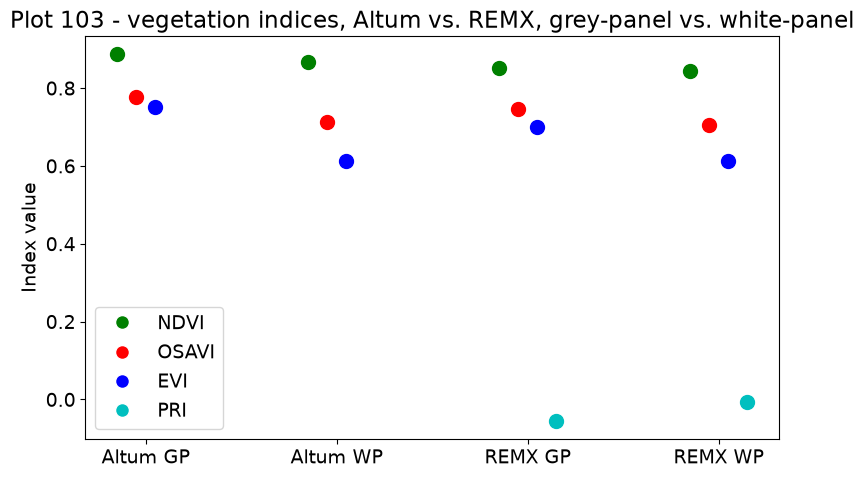

In [9]:
# Step 5b: plot the indices (one coloured point per index, same colours as in the other notebooks).
fig, ax = plt.subplots(figsize=(8, 5))
index_colors = {'NDVI': 'g', 'OSAVI': 'r', 'EVI': 'b', 'PRI': 'c'}
offsets = {'NDVI': -0.15, 'OSAVI': -0.05, 'EVI': 0.05, 'PRI': 0.15}
for x, product in enumerate(computed_df.index):
    for idx_name, color in index_colors.items():
        val = computed_df.loc[product, idx_name]
        if pd.notna(val):
            ax.plot(x + offsets[idx_name], val, 'o', color=color, markersize=10)
ax.set_xticks(range(len(computed_df.index))); ax.set_xticklabels(computed_df.index)
ax.set_ylabel('Index value')
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=10, label=n)
           for n, c in index_colors.items()]
ax.legend(handles=handles)
ax.set_title('Plot 103 - vegetation indices, Altum vs. REMX, grey-panel vs. white-panel')
plt.tight_layout()
plt.show()

## Step 6 - Vegetation indices and their uncertainty

In [10]:
# Step 6: vegetation indices and their combined uncertainty u_c from the campaign workbook, sheet Indexes103.
# One row per camera and method (Altum GP = row 31, Altum WP = row 32, REMX GP = row 37, REMX WP = row 38).
# Each index occupies a block of 7 columns: point, value, u_r, u_s, u_homogeneity, u_c, U_k2.
ws_idx = wb["Indexes103"]
rows_idx = {'Altum GP': 31, 'Altum WP': 32, 'REMX GP': 37, 'REMX WP': 38}
index_start = {"NDVI": 7, "EVI": 19, "OSAVI": 31, "PRI": 1}   # first column of each block: value = start+1, u_c = start+5

records = []
for product, r in rows_idx.items():
    for name, start in index_start.items():
        value = ws_idx.cell(row=r, column=start + 1).value
        u_c = ws_idx.cell(row=r, column=start + 5).value
        if value is not None:
            records.append(dict(product=product, index=name, value=value, u_c=u_c))
workbook_indices = pd.DataFrame(records)
workbook_indices.pivot(index='product', columns='index', values=['value', 'u_c']).round(4)

value                             u_c                        
index        EVI    NDVI   OSAVI     PRI     EVI    NDVI   OSAVI     PRI
product                                                                 
Altum GP  0.7512  0.8865  0.7765     NaN  0.0094  0.0070  0.0063     NaN
Altum WP  0.6126  0.8673  0.7130     NaN  0.0083  0.0080  0.0067     NaN
REMX GP   0.7001  0.8512  0.7462 -0.0543  0.0061  0.0052  0.0049  0.0089
REMX WP   0.6121  0.8439  0.7058 -0.0064  0.0055  0.0054  0.0049  0.0021

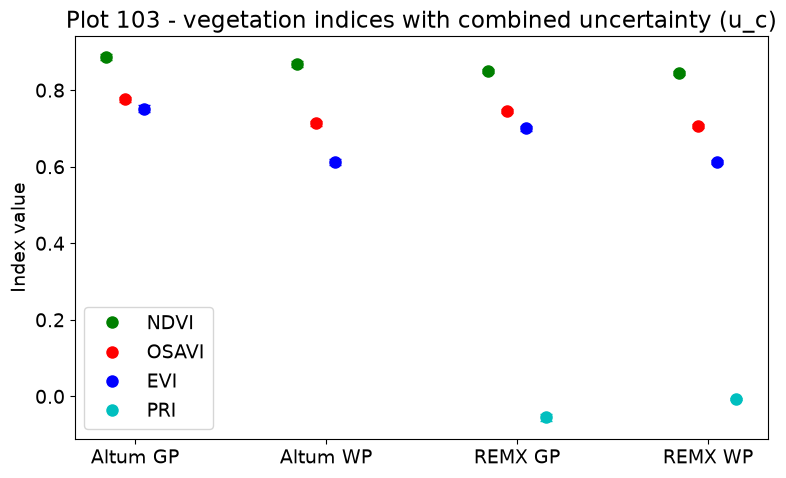

In [11]:
# Step 6b: indices with their combined uncertainty (error bars, one colour per index)
fig, ax = plt.subplots(figsize=(8, 5))
index_colors = {'NDVI': 'g', 'OSAVI': 'r', 'EVI': 'b', 'PRI': 'c'}
offsets = {'NDVI': -0.15, 'OSAVI': -0.05, 'EVI': 0.05, 'PRI': 0.15}
products = list(rows_idx)
for x, product in enumerate(products):
    for idx_name, color in index_colors.items():
        sel = workbook_indices[(workbook_indices['product'] == product) & (workbook_indices['index'] == idx_name)]
        if len(sel):
            ax.errorbar(x + offsets[idx_name], sel['value'].iloc[0], yerr=sel['u_c'].iloc[0],
                        fmt='o', color=color, capsize=4, markersize=8)
ax.set_xticks(range(len(products))); ax.set_xticklabels(products)
ax.set_ylabel('Index value')
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=10, label=n)
           for n, c in index_colors.items()]
ax.legend(handles=handles)
ax.set_title('Plot 103 - vegetation indices with combined uncertainty (u_c)')
plt.tight_layout()
plt.show()

---

**Code:** Álvaro Sánchez-Virosta  
**Training material:** L. Mihai (laura.mihai@inflpr.ro)